# Hormuz Cable Risk
## Geopolitical Risk Index for Submarine Cable Infrastructure in the Strait of Hormuz

This notebook documents the full analysis pipeline: data sources, methodology, results, and limitations.

**Data coverage:** 1989 – February 2026  
**Author:** Carolina Cruz  
**Repository:** [github.com/CarolinaMCruz/hormuz-cable-risk](https://github.com/CarolinaMCruz/hormuz-cable-risk)

## 1. Context

The Strait of Hormuz is the world's most critical maritime chokepoint for oil transport. Less discussed is its role as a submarine cable corridor connecting the Gulf states to Europe and Asia.

This project asks: **if cables in this zone are damaged, which countries lose the most digital connectivity?**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load processed datasets
df_cables   = pd.read_csv('../data/processed/cables.csv')
df_landing  = pd.read_csv('../data/processed/landing_points.csv')
df_conflicto = pd.read_csv('../data/processed/ucdp_gulf_zone.csv', low_memory=False)
df_indice   = pd.read_csv('../data/processed/indice_riesgo.csv')

print(f"Cables: {len(df_cables)}")
print(f"Landing points: {len(df_landing)}")
print(f"Conflict events: {len(df_conflicto):,}")
print(f"Countries in index: {len(df_indice)}")

Cables: 691
Landing points: 3157
Conflict events: 25,673
Countries in index: 10


## 2. Infrastructure Overview

### 2.1 Submarine Cables in the Gulf Zone

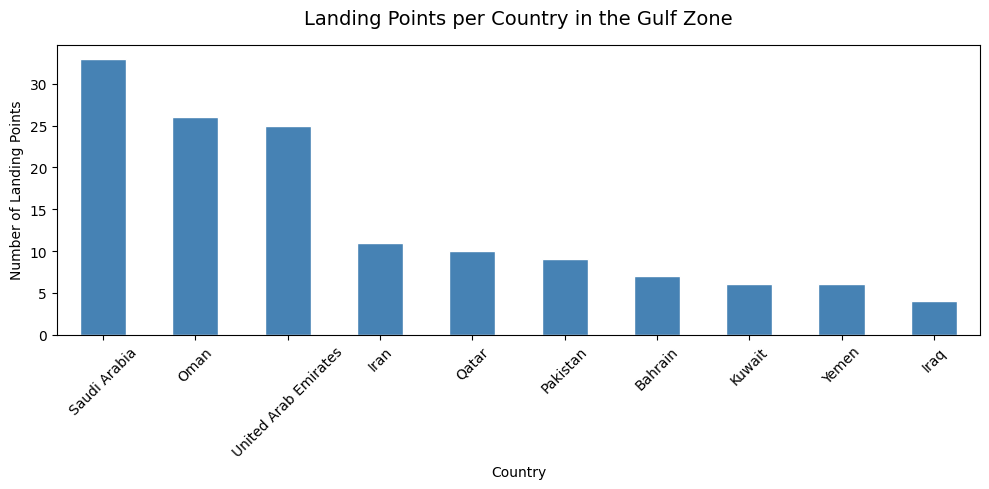


Total landing points in zone: 137
country
Saudi Arabia            33
Oman                    26
United Arab Emirates    25
Iran                    11
Qatar                   10
Pakistan                 9
Bahrain                  7
Kuwait                   6
Yemen                    6
Iraq                     4


In [4]:
ZONA = [
    "Iran", "Oman", "Yemen", "Saudi Arabia",
    "United Arab Emirates", "Qatar", "Kuwait", "Bahrain",
    "Pakistan", "Iraq"
]

# Landing points per country in the Gulf zone
lp_zona = df_landing[df_landing["country"].isin(ZONA)]
conteo = lp_zona["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Landing Points per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Landing Points")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal landing points in zone: {len(lp_zona)}")
print(conteo.to_string())

### 2.2 Cables per Country

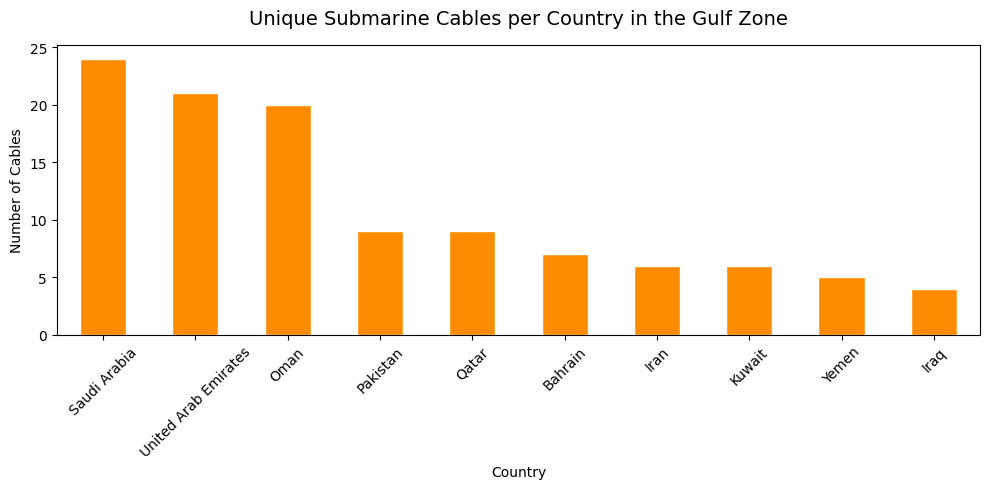


Cables per country:
country
Saudi Arabia            24
United Arab Emirates    21
Oman                    20
Pakistan                 9
Qatar                    9
Bahrain                  7
Iran                     6
Kuwait                   6
Yemen                    5
Iraq                     4


In [5]:
# Unique cables per country in zone
cables_pais = (
    lp_zona.groupby("country")["cable_id"]
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
cables_pais.plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_title("Unique Submarine Cables per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Cables")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nCables per country:")
print(cables_pais.to_string())

### 2.3 Conflict Events in the Gulf Zone (1989-2026)

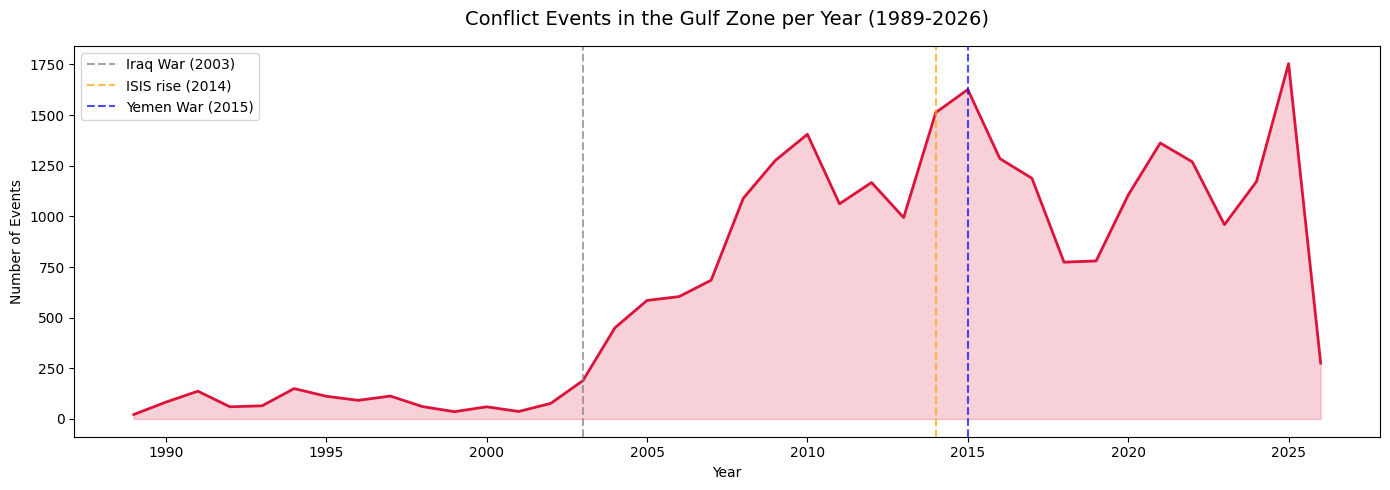

In [6]:
df_conflicto["date_start"] = pd.to_datetime(df_conflicto["date_start"])
df_conflicto["year"] = df_conflicto["date_start"].dt.year
df_conflicto["country"] = df_conflicto["country"].replace({"Yemen (North Yemen)": "Yemen"})

# Events per year
eventos_año = df_conflicto.groupby("year").size()

fig, ax = plt.subplots(figsize=(14, 5))
eventos_año.plot(kind="line", ax=ax, color="crimson", linewidth=2)
ax.fill_between(eventos_año.index, eventos_año.values, alpha=0.2, color="crimson")
ax.set_title("Conflict Events in the Gulf Zone per Year (1989-2026)", fontsize=14, pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.axvline(x=2003, color="gray", linestyle="--", alpha=0.7, label="Iraq War (2003)")
ax.axvline(x=2014, color="orange", linestyle="--", alpha=0.7, label="ISIS rise (2014)")
ax.axvline(x=2015, color="blue", linestyle="--", alpha=0.7, label="Yemen War (2015)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Conflict Events by Country


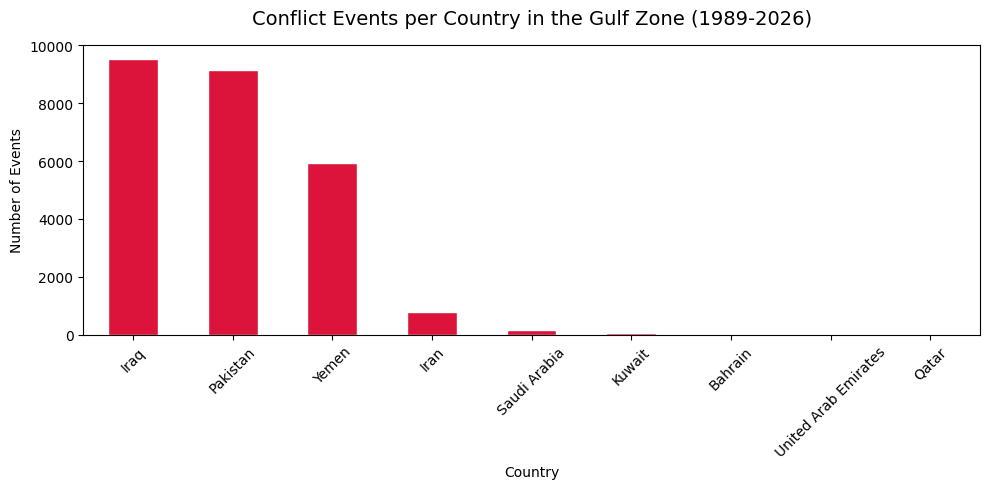


Events per country:
country
Iraq                    9540
Pakistan                9153
Yemen                   5941
Iran                     794
Saudi Arabia             173
Kuwait                    41
Bahrain                   24
United Arab Emirates       5
Qatar                      2


In [8]:
# Events per country
eventos_pais = df_conflicto["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
eventos_pais.plot(kind="bar", ax=ax, color="crimson", edgecolor="white")
ax.set_title("Conflict Events per Country in the Gulf Zone (1989-2026)", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Events")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nEvents per country:")
print(eventos_pais.to_string())

## 3. Digital Vulnerability Index

### 3.1 Risk Index by Country

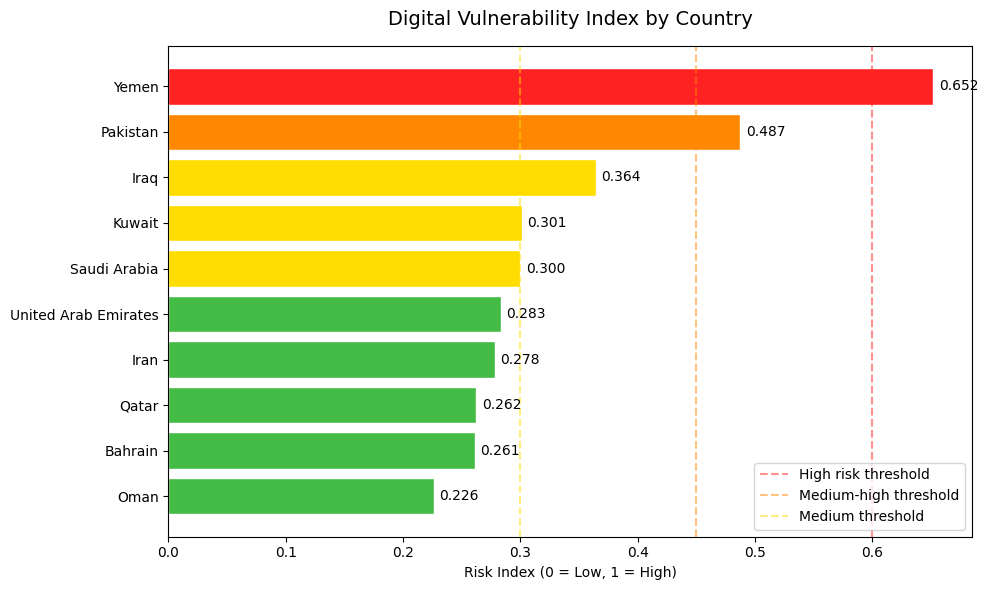

In [9]:
df_indice_sorted = df_indice.sort_values("indice_riesgo", ascending=True)

colors = []
for val in df_indice_sorted["indice_riesgo"]:
    if val >= 0.6:
        colors.append("#ff2222")
    elif val >= 0.45:
        colors.append("#ff8800")
    elif val >= 0.30:
        colors.append("#ffdd00")
    else:
        colors.append("#44bb44")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_indice_sorted["country"], df_indice_sorted["indice_riesgo"],
               color=colors, edgecolor="white")

ax.set_title("Digital Vulnerability Index by Country", fontsize=14, pad=15)
ax.set_xlabel("Risk Index (0 = Low, 1 = High)")
ax.axvline(x=0.60, color="#ff2222", linestyle="--", alpha=0.5, label="High risk threshold")
ax.axvline(x=0.45, color="#ff8800", linestyle="--", alpha=0.5, label="Medium-high threshold")
ax.axvline(x=0.30, color="#ffdd00", linestyle="--", alpha=0.5, label="Medium threshold")

for bar, val in zip(bars, df_indice_sorted["indice_riesgo"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10)

ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 3.2 Index Components Breakdown

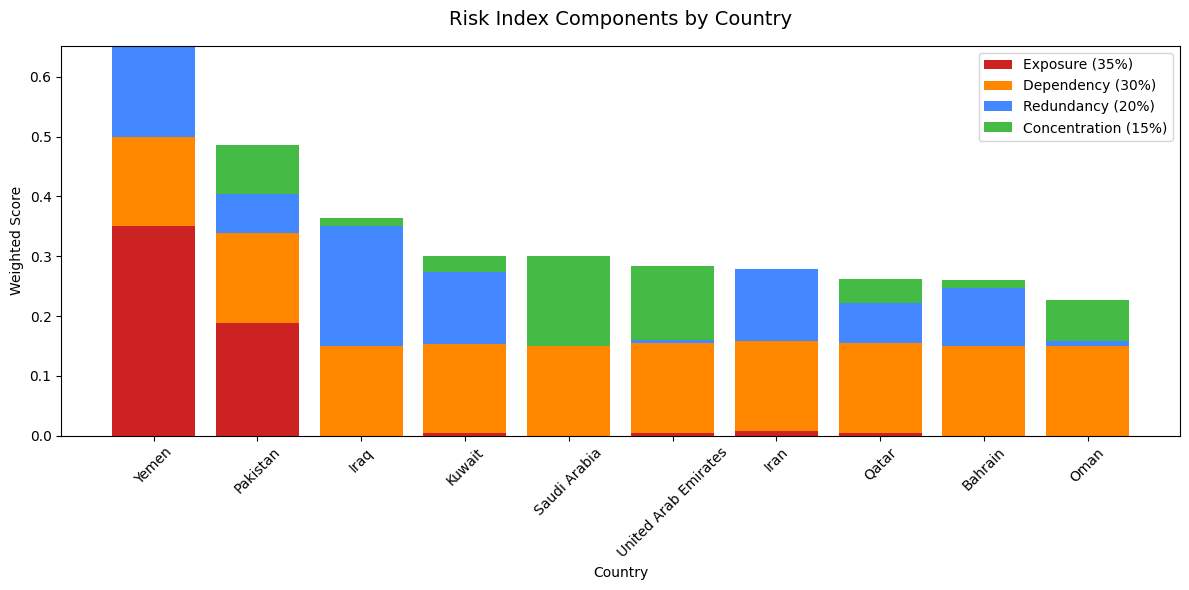

In [10]:
df_plot = df_indice.sort_values("indice_riesgo", ascending=False).copy()

# Weighted components
df_plot["w_exposicion"]    = df_plot["n_exposicion"] * 0.35
df_plot["w_dependencia"]   = df_plot["n_dependencia"] * 0.30
df_plot["w_redundancia"]   = df_plot["n_redundancia"] * 0.20
df_plot["w_concentracion"] = df_plot["n_concentracion"] * 0.15

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(df_plot["country"], df_plot["w_exposicion"],    label="Exposure (35%)",       color="#cc2222")
ax.bar(df_plot["country"], df_plot["w_dependencia"],   label="Dependency (30%)",     color="#ff8800",
       bottom=df_plot["w_exposicion"])
ax.bar(df_plot["country"], df_plot["w_redundancia"],   label="Redundancy (20%)",     color="#4488ff",
       bottom=df_plot["w_exposicion"] + df_plot["w_dependencia"])
ax.bar(df_plot["country"], df_plot["w_concentracion"], label="Concentration (15%)",  color="#44bb44",
       bottom=df_plot["w_exposicion"] + df_plot["w_dependencia"] + df_plot["w_redundancia"])

ax.set_title("Risk Index Components by Country", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Weighted Score")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. Key Findings

In [13]:
print("=" * 55)
print("  KEY FINDINGS")
print("=" * 55)

# País más vulnerable
top = df_indice.iloc[0]
print(f"\n1. Most vulnerable country: {top['country']}")
print(f"   Risk index: {top['indice_riesgo']}")
print(f"   Cables: {int(top['cables_totales'])} (all in risk zone)")
print(f"   Conflict events near cables: {int(top['eventos_totales'])}")

# País más resiliente
bottom = df_indice.iloc[-1]
print(f"\n2. Most resilient country: {bottom['country']}")
print(f"   Risk index: {bottom['indice_riesgo']}")
print(f"   Cables: {int(bottom['cables_totales'])} (high redundancy)")
print(f"   Conflict events near cables: {int(bottom['eventos_totales'])}")

# Cables críticos
print(f"\n3. Critical cables (pass through Iran or Yemen):")
criticos = df_landing[
    df_landing["country"].isin(["Iran", "Yemen"])
]["cable_name"].value_counts()
for cable, _ in criticos.head(5).items():
    print(f"   - {cable}")

# Concentración
print(f"\n4. Single points of failure:")
cables_por_lp = df_landing.groupby(["landing_id","landing_name","country"]).size().reset_index(name="n_cables")
spof = cables_por_lp[
    cables_por_lp["country"].isin(["Iran","Yemen","Iraq"]) &
    (cables_por_lp["n_cables"] >= 3)
].sort_values("n_cables", ascending=False)
print(spof[["landing_name","country","n_cables"]].to_string(index=False))

  KEY FINDINGS

1. Most vulnerable country: Yemen
   Risk index: 0.652
   Cables: 5 (all in risk zone)
   Conflict events near cables: 569

2. Most resilient country: Oman
   Risk index: 0.226
   Cables: 20 (high redundancy)
   Conflict events near cables: 0

3. Critical cables (pass through Iran or Yemen):
   - FALCON
   - Kuwait-Iran
   - OMRAN/EPEG
   - Pishgaman Oman Iran (POI) Network
   - Aden-Djibouti

4. Single points of failure:
      landing_name country  n_cables
      Al Faw, Iraq    Iraq         4
Al Hudaydah, Yemen   Yemen         3
    Chabahar, Iran    Iran         3
        Jask, Iran    Iran         3


## 5. Limitations

- **UCDP coverage:** Verified armed conflict events only. Naval operations, cyber attacks, and geopolitical pressure are not captured, likely underestimating Iran's actual risk.
- **Cable geometry:** TeleGeography routes are cartographic representations, not precise engineering data.
- **Exposure radius:** 50km buffer around landing points. Cables between landing points are not analyzed.
- **AISstream:** Real-time vessel tracking was tested but the service was unavailable at time of development.
- **GFW vessel presence:** Access to the `public-global-vessel-presence` dataset was requested but not granted.

## 6. Data Sources

- TeleGeography Submarine Cable Map: https://www.submarinecablemap.com
- UCDP Georeferenced Event Dataset v25.1: https://ucdp.uu.se/downloads
- UCDP Candidate Dataset v26.0.2: https://ucdp.uu.se/downloads
- AISstream: https://aisstream.io